# Customer 360 — Revenue Prediction

This notebook develops regression models to predict customers' future 12-month revenue. Several regression algorithms are compared using MAE, RMSE, and R², followed by evaluation and analysis of the final revenue model.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.model_selection import train_test_split,KFold,cross_val_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import joblib

In [2]:
df = pd.read_csv("../Dataset/customer_360_ml_workshop.csv")

## Data Preprocessing

The train/test split is performed **before** any model fitting. A reusable `ColumnTransformer` handles:

- numerical variables: median imputation → standardization
- categorical variables: most-frequent imputation → one-hot encoding
- `handle_unknown="ignore"` for unseen categories

The transformer is placed inside model pipelines, so each model learns preprocessing only from its training data.

In [3]:
x = df.drop(columns=["CustomerID", "Churn", "Future12MRevenueEGP"])
y_regression = df["Future12MRevenueEGP"]

In [4]:
x_train_r, x_test_r, y_train_r, y_test_r = train_test_split(
    x, y_regression,
    test_size=0.20,
    random_state=42
)

In [5]:
numeric_features = x.select_dtypes(include='number').columns.tolist()
categorical_features = x.select_dtypes(include='str').columns.tolist()

In [6]:
preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric_features),

    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]), categorical_features)
])

In [7]:
print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)

Numerical features: ['Age', 'TenureMonths', 'MonthlyUsageGB', 'MonthlyChargeEGP', 'NumServices', 'SupportCalls6M', 'LatePayments12M', 'SatisfactionScore']
Categorical features: ['Region', 'ContractType', 'InternetType', 'PaperlessBilling', 'AutoPay']


## Future 12-Month Revenue Regression

Target: `Future12MRevenueEGP`.

`Churn` is not used as a feature because it is another outcome in this dataset. The regression models use the same customer attributes available before the future revenue outcome.

The test set remains untouched during model selection. Cross-validation on the training set is used to compare models before the final test evaluation.

In [8]:
regression_models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(random_state=42),
    "Lasso": Lasso(random_state=42),
    "KNN Regressor": KNeighborsRegressor(),
    "Decision Tree Regressor": DecisionTreeRegressor(random_state=42),
    "Random Forest Regressor": RandomForestRegressor(random_state=42),
    "Gradient Boosting Regressor": GradientBoostingRegressor(random_state=42)
}

regression_pipelines = {
    name: Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    for name, model in regression_models.items()
}

In [9]:
cv_reg = KFold(n_splits=5, shuffle=True, random_state=42)

regression_results = []

for name, model in regression_pipelines.items():
    cv_r2 = cross_val_score(model, x_train_r, y_train_r,cv=cv_reg, scoring="r2", n_jobs=-1).mean()

    model.fit(x_train_r, y_train_r)
    pred = model.predict(x_test_r)

    regression_results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test_r, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test_r, pred)),
        "R²": r2_score(y_test_r, pred),
        "CV R²": cv_r2
    })

regression_results = pd.DataFrame(regression_results).sort_values("CV R²", ascending=False)

regression_results.round(3)

,Model,MAE,RMSE,R²,CV R²
6,Gradient Boosting Regressor,368.560,464.972,0.897,0.902
2,Lasso,378.672,475.086,0.892,0.899
1,Ridge,378.417,474.915,0.892,0.899
0,Linear Regression,378.427,474.928,0.892,0.899
5,Random Forest Regressor,393.555,496.139,0.883,0.893
4,Decision Tree Regressor,537.060,683.954,0.777,0.792
3,KNN Regressor,619.291,783.499,0.707,0.745


In [10]:
best_reg_name = regression_results.iloc[0]["Model"]
best_reg_model = regression_pipelines[best_reg_name]

best_reg_pred = best_reg_model.predict(x_test_r)

print(f"Selected revenue model based on training CV R²: {best_reg_name}")
print(f"Test MAE: {mean_absolute_error(y_test_r, best_reg_pred):,.2f} EGP")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test_r, best_reg_pred)):,.2f} EGP")
print(f"Test R²: {r2_score(y_test_r, best_reg_pred):.3f}")

Selected revenue model based on training CV R²: Gradient Boosting Regressor
Test MAE: 368.56 EGP
Test RMSE: 464.97 EGP
Test R²: 0.897


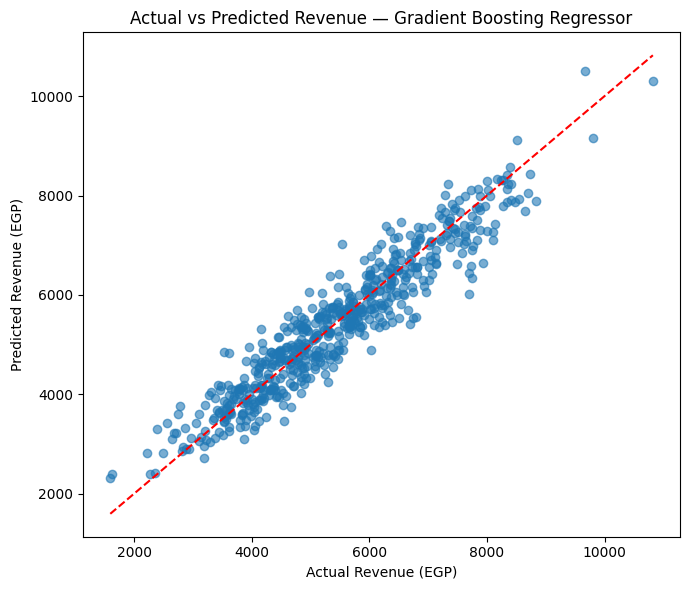

In [11]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test_r, best_reg_pred, alpha=0.6)

lims = [min(y_test_r.min(), best_reg_pred.min()),max(y_test_r.max(), best_reg_pred.max())]

plt.plot(lims, lims, "--",color='red')
plt.xlabel("Actual Revenue (EGP)")
plt.ylabel("Predicted Revenue (EGP)")
plt.title(f"Actual vs Predicted Revenue — {best_reg_name}")
plt.tight_layout()
plt.show()

In [12]:
joblib.dump(best_reg_model, "../models/revenue_model.pkl")

['../models/revenue_model.pkl']